#Library

In [ ]:
# Google Colab
from google.colab import drive

# Data Processing
import os
import tempfile
import itertools
import warnings
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Machine Learning & Evaluation
from sklearn.preprocessing import (
    LabelEncoder,
    normalize)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold)
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    silhouette_score)

# FastText
!pip install fasttext
import fasttext
import fasttext.util

# TensorFlow / Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LSTM,
    Bidirectional)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau)
from tensorflow.keras.regularizers import l2

# Transformer
from transformers import (
    AutoTokenizer,
    AutoModel)

# PyTorch
import torch

from tensorflow.keras.preprocessing.sequence import pad_sequences

warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653913 sha256=1948805ec6a7e0636685260759ac08d4a0e67562938e5f0cef88ece207073c37
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import torch

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

# jika pakai GPU
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# agar hasil lebih reproducible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
import torch

print("CUDA available :", torch.cuda.is_available())
print("CUDA version   :", torch.version.cuda)
print("GPU count      :", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name       :", torch.cuda.get_device_name(0))

CUDA available : False
CUDA version   : None
GPU count      : 0


#RAM & TIMER

In [ ]:
# ============================================================
# TIMER & RAM MONITORING
# ============================================================

import time
import psutil

time_records = []

def get_ram_usage():

    ram = psutil.virtual_memory()

    return round(
        ram.used / (1024**3),
        4
    )

def simpan_monitoring(
    metode,
    tahap,
    parameter,
    waktu,
    ram_before,
    ram_after
):

    time_records.append({

        "Metode": metode,
        "Tahap": tahap,
        "Parameter": parameter,

        "Waktu (detik)": round(
            waktu,
            4
        ),

        "RAM Sebelum (GB)": round(
            ram_before,
            4
        ),

        "RAM Sesudah (GB)": round(
            ram_after,
            4
        ),

        "Kenaikan RAM (GB)": round(
            ram_after - ram_before,
            4
        )
    })

#Input Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
drive.mount('/content/drive')
df = pd.read_excel(
    '/content/drive/MyDrive/Thesis/data/hasil_normalisasi.xlsx',
    sheet_name='All',
    engine='openpyxl'
)
df_clean = df[['text_clean1', 'Labelling_clean']]
df_clean

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,text_clean1,Labelling_clean
0,memang mandiri menguras uang sekali omong-omon...,negatif
1,utbk tinggal beberapa bulan lagi,netral
2,cari beasiswa saudara kalau kipk sistemnya har...,positif
3,saat belajar utbk sampai meninggal,negatif
4,teman-teman anak fib sastra bahasa ada ikut u...,netral
...,...,...
1193,walaupun capek tapi seru juga punya teman sepe...,positif
1194,semangat terus buat yang lagi persiapan utbk k...,positif
1195,senang karena akhirnya berani daftar jurusan y...,positif
1196,semoga semua doa baik tentang ptn impian bisa ...,positif


#Exploration

In [ ]:
# Documents
documents = df_clean['text_clean1'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else x
).tolist()

# Labels
le = LabelEncoder()
y_encoded = le.fit_transform(df['Labelling_clean'])
num_classes = len(le.classes_)

# Sequence length
doc_lengths = df['text_clean'].apply(lambda x: len(str(x).split()))
seq_length = int(np.percentile(doc_lengths, 85))

# 🔹 Total jumlah kata
total_words = sum(len(doc.split()) for doc in documents)

# 🔹 Jumlah kata unik (vocabulary size)
unique_words = len(set(word for doc in documents for word in doc.split()))

print(f"Documents: {len(documents)}")
print(f"Num classes: {num_classes}")
print(f"Seq length: {seq_length}")
print(f"Total words: {total_words}")
print(f"Unique words: {unique_words}")

Documents: 1198
Num classes: 3
Seq length: 28
Total words: 18108
Unique words: 2831


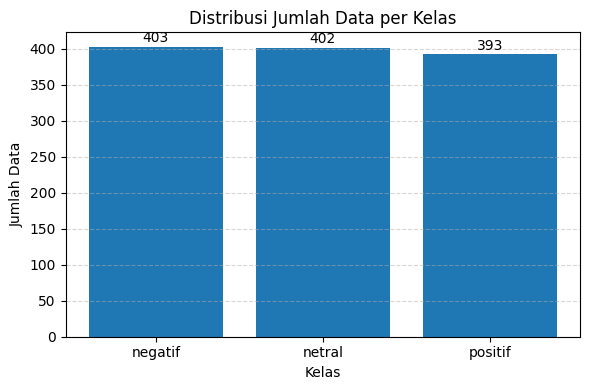

In [ ]:
label_counts = df['Labelling_clean'].value_counts()

plt.figure(figsize=(6,4))

bars = plt.bar(
    label_counts.index,
    label_counts.values
)

plt.title('Distribusi Jumlah Data per Kelas')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Data')

# tampilkan angka di atas bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        str(bar.get_height()),
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#Split Data

In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    documents,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

###Convert ke Text

In [ ]:
with tempfile.NamedTemporaryFile(mode='w', delete=False,
                                 encoding='utf-8',
                                 suffix='_train.txt') as f_train:

    for doc in X_train_text:
        f_train.write(doc + '\n')

    train_txt_path = f_train.name

with tempfile.NamedTemporaryFile(mode='w', delete=False,
                                 encoding='utf-8',
                                 suffix='_test.txt') as f_test:

    for doc in X_test_text:
        f_test.write(doc + '\n')

    test_txt_path = f_test.name

print("Train:", len(X_train_text))
print("Test :", len(X_test_text))

print("\nTrain TXT:", train_txt_path)
print("Test TXT :", test_txt_path)

Train: 958
Test : 240

Train TXT: /tmp/tmpu66j9qae_train.txt
Test TXT : /tmp/tmpoeo4ej4g_test.txt


###Perbandingan Jumlah Kelas

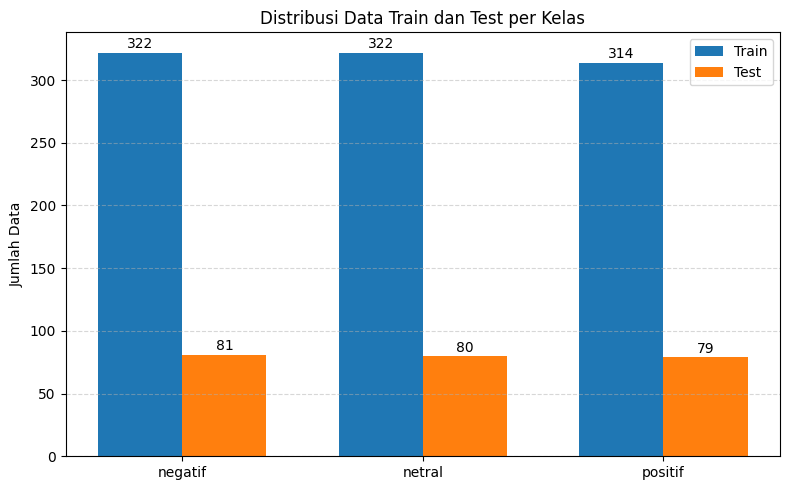

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

classes = list(le.classes_)
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()

x = np.arange(len(classes))
width = 0.35
plt.figure(figsize=(8,5))

bars1 = plt.bar( x - width/2, train_counts.values, width,label='Train')
bars2 = plt.bar( x + width/2, test_counts.values, width,label='Test')

plt.xticks(x, classes)
plt.ylabel('Jumlah Data')
plt.title('Distribusi Data Train dan Test per Kelas')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bars in [bars1, bars2]:
    for bar in bars: plt.text(bar.get_x() + bar.get_width()/2,bar.get_height() + 1,f'{int(bar.get_height())}',ha='center',va='bottom')

plt.tight_layout()
plt.show()

#Train

##FastText Train

In [ ]:
!pip install fasttext
import fasttext
import fasttext.util
import numpy as np
import pandas as pd
import itertools
import tempfile
import os
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import itertools
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import fasttext
import warnings
from tensorflow.keras.preprocessing.sequence import pad_sequences
warnings.filterwarnings('ignore')

####Kombinasi Parameter


In [ ]:
param_grid = {

    'dim'   : [50, 100],

    'epoch' : [10, 25],

    'lr'    : [0.1, 0.5]
}

combinations = list(

    itertools.product(

        param_grid['dim'],

        param_grid['epoch'],

        param_grid['lr']
    )
)

print(
    "Jumlah kombinasi:",
    len(combinations)
)

Jumlah kombinasi: 8


## 1: RAM & Timer Pretrained

####Ekstraksi Fitur

In [ ]:
def get_word_embeddings(model, texts, max_len):

    sequences = []

    for text in texts:

        words = text.split()

        word_vectors = []

        for w in words[:max_len]:

            vec = model.get_word_vector(w)

            word_vectors.append(vec)

        sequences.append(word_vectors)

    # padding
    padded = pad_sequences(
        sequences,
        maxlen=max_len,
        dtype='float32',
        padding='post',
        truncating='post'
    )

    return np.array(padded)

In [ ]:
# ============================================================
# FASTTEXT + EKSTRAK EMBEDDING + MONITORING
# ============================================================

all_bilstm_data = {}

for dim, epoch, lr in itertools.product(

    param_grid['dim'],

    param_grid['epoch'],

    param_grid['lr']
):

    print("\n" + "="*60)

    print(

        f"dim={dim}, "

        f"ep={epoch}, "

        f"lr={lr}"
    )

    # ========================================================
    # TIMER START
    # ========================================================

    ram_before = get_ram_usage()

    start_time = time.perf_counter()

    # ========================================================
    # TRAIN FASTTEXT
    # ========================================================

    model = fasttext.train_unsupervised(

        train_txt_path,

        model='skipgram',

        dim=dim,

        minn=3,

        maxn=5,

        epoch=epoch,

        lr=lr,

        wordNgrams=1,

        thread=4,

        verbose=0
    )

    # ========================================================
    # EKSTRAK WORD EMBEDDING
    # ========================================================

    X_bilstm = get_word_embeddings(

        model,

        X_train_text,

        seq_length
    )

    # ========================================================
    # TIMER END
    # ========================================================

    end_time = time.perf_counter()

    ram_after = get_ram_usage()

    elapsed_time = (
        end_time - start_time
    )

    # ========================================================
    # KEY MODEL
    # ========================================================

    key = (

        f"d{dim}_"

        f"ep{epoch}_"

        f"lr{lr}"
    )

    # ========================================================
    # SIMPAN DATA
    # ========================================================

    all_bilstm_data[key] = {

        'X_bilstm' : X_bilstm,

        'fasttext_model' : model,

        'dim' : dim,

        'epoch' : epoch,

        'lr' : lr,

        'wordNgrams' : 1
    }

    # ========================================================
    # SIMPAN MONITORING
    # ========================================================

    simpan_monitoring(

        metode="FastText + BiLSTM",

        tahap="Embedding Extraction",

        parameter=(

            f"dim={dim}, "

            f"epoch={epoch}, "

            f"lr={lr}"
        ),

        waktu=elapsed_time,

        ram_before=ram_before,

        ram_after=ram_after
    )

    # ========================================================
    # OUTPUT
    # ========================================================

    print(
        "Shape X :",
        X_bilstm.shape
    )

    print(

        f"Waktu : "

        f"{elapsed_time:.2f} detik"
    )

    print(

        f"RAM : "

        f"{ram_before:.2f} GB -> "

        f"{ram_after:.2f} GB"
    )


dim=50, ep=10, lr=0.1
Shape X : (958, 28, 50)
Waktu : 0.67 detik
RAM : 2.14 GB -> 1.60 GB

dim=50, ep=10, lr=0.5
Shape X : (958, 28, 50)
Waktu : 0.68 detik
RAM : 1.60 GB -> 1.96 GB

dim=50, ep=25, lr=0.1
Shape X : (958, 28, 50)
Waktu : 0.81 detik
RAM : 1.96 GB -> 2.27 GB

dim=50, ep=25, lr=0.5
Shape X : (958, 28, 50)
Waktu : 0.81 detik
RAM : 2.27 GB -> 2.58 GB

dim=100, ep=10, lr=0.1
Shape X : (958, 28, 100)
Waktu : 0.94 detik
RAM : 2.58 GB -> 3.08 GB

dim=100, ep=10, lr=0.5
Shape X : (958, 28, 100)
Waktu : 0.92 detik
RAM : 3.08 GB -> 3.56 GB

dim=100, ep=25, lr=0.1
Shape X : (958, 28, 100)
Waktu : 1.22 detik
RAM : 3.56 GB -> 4.03 GB

dim=100, ep=25, lr=0.5
Shape X : (958, 28, 100)
Waktu : 1.32 detik
RAM : 4.03 GB -> 4.53 GB


#BiLSTM Train

In [ ]:
import itertools
import numpy as np
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score
)
from sklearn.model_selection import StratifiedKFold

###Kombinasi Parameter

In [ ]:
epochs_list = [10, 20]
batch_size_list = [64]
results = []

###Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)

###Persiapan Data Train

In [ ]:
results = []

for key, data in all_bilstm_data.items():

    print(f"\nModel : {key}")

    X = np.array(
        data["X_bilstm"]
    )

    y = np.array(y_train)

    if len(X) != len(y):

        print("Jumlah data tidak sama")
        continue

    print("Shape X :", X.shape)

    print("Shape y :", y.shape)


Model : d50_ep10_lr0.1
Shape X : (958, 28, 50)
Shape y : (958,)

Model : d50_ep10_lr0.5
Shape X : (958, 28, 50)
Shape y : (958,)

Model : d50_ep25_lr0.1
Shape X : (958, 28, 50)
Shape y : (958,)

Model : d50_ep25_lr0.5
Shape X : (958, 28, 50)
Shape y : (958,)

Model : d100_ep10_lr0.1
Shape X : (958, 28, 100)
Shape y : (958,)

Model : d100_ep10_lr0.5
Shape X : (958, 28, 100)
Shape y : (958,)

Model : d100_ep25_lr0.1
Shape X : (958, 28, 100)
Shape y : (958,)

Model : d100_ep25_lr0.5
Shape X : (958, 28, 100)
Shape y : (958,)


###Arsitektur BiLSTM

In [ ]:
def build_bilstm_model(input_shape):

    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(
            LSTM(64,
                dropout=0.5,
                recurrent_dropout=0.5,
                kernel_regularizer=l2(1e-4)) ),
        Dense(64,
            activation='relu',
            kernel_regularizer=l2(1e-4)),

        Dropout(0.5),
        Dense(3, activation='softmax')])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy'])

    return model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5)

## 3: RAM & Timer Tunning ⏲

###Tunning Hiperparameter

In [ ]:
import tensorflow as tf
from tensorflow.keras.regularizers import l2

results = []

all_fold_scores = []

# ============================================================
# LOOP EMBEDDING
# ============================================================

for key, data in all_bilstm_data.items():

    print(f"\n===== {key} =====")

    X = np.array(data["X_bilstm"])
    y = np.array(y_train)

    if len(X) != len(y):

        print("Jumlah data tidak sama")
        continue

    # ========================================================
    # LOOP EPOCH
    # ========================================================

    for epochs in epochs_list:

        # ====================================================
        # LOOP BATCH SIZE
        # ====================================================

        for batch_size in batch_size_list:

            # =================================================
            # RAM SEBELUM TRAINING
            # =================================================

            ram_before = get_ram_usage()

            # =================================================
            # TIMER MULAI
            # =================================================

            start_train = time.perf_counter()

            accs = []

            # =================================================
            # CROSS VALIDATION
            # =================================================

            for fold, (
                train_idx,
                val_idx
            ) in enumerate(

                skf.split(X, y),
                start=1
            ):

                tf.keras.backend.clear_session()

                X_train_fold = X[train_idx]
                X_val_fold   = X[val_idx]

                y_train_fold = y[train_idx]
                y_val_fold   = y[val_idx]

                # =============================================
                # BUILD MODEL
                # =============================================

                model = build_bilstm_model(

                    input_shape=(

                        X.shape[1],

                        X.shape[2]
                    )
                )

                # =============================================
                # TRAINING
                # =============================================

                model.fit(

                    X_train_fold,

                    y_train_fold,

                    validation_data=(

                        X_val_fold,

                        y_val_fold
                    ),

                    epochs=epochs,

                    batch_size=batch_size,

                    callbacks=[

                        early_stop,

                        reduce_lr
                    ],

                    verbose=0
                )

                # =============================================
                # EVALUASI
                # =============================================

                _, acc = model.evaluate(

                    X_val_fold,

                    y_val_fold,

                    verbose=0
                )

                accs.append(acc)

            # =================================================
            # TIMER SELESAI
            # =================================================

            end_train = time.perf_counter()

            waktu_train = (
                end_train - start_train
            )

            # =================================================
            # RAM SESUDAH TRAINING
            # =================================================

            ram_after = get_ram_usage()

            ram_used = (
                ram_after - ram_before
            )

            # =================================================
            # METRIK
            # =================================================

            mean_acc = np.mean(accs)

            std_acc = np.std(accs)

            # =================================================
            # PRINT HASIL
            # =================================================

            print(
                f"\nep={epochs} | "
                f"bs={batch_size} | "
                f"acc={mean_acc:.4f} ± {std_acc:.4f} | "
                f"waktu={waktu_train:.2f} detik | "
                f"RAM={ram_after:.2f} GB"
            )

            print(
                f"Kenaikan RAM : "
                f"{ram_used:.2f} GB"
            )

            for i, fold_acc in enumerate(
                accs,
                start=1
            ):

                print(
                    f"Fold {i} Accuracy : "
                    f"{fold_acc:.4f}"
                )

            # =================================================
            # SIMPAN MONITORING
            # =================================================

            simpan_monitoring(

                metode="FastText-BiLSTM",

                tahap="Training CV",

                parameter=(
                    f"{key}, "
                    f"ep={epochs}, "
                    f"bs={batch_size}"
                ),

                waktu=waktu_train,

                ram_before=ram_before,

                ram_after=ram_after
            )

            # =================================================
            # SIMPAN HASIL
            # =================================================

            result_dict = {

                "model": key,

                "epochs": epochs,

                "batch_size": batch_size,

                "mean_accuracy": mean_acc,

                "std": std_acc,

                "waktu_training": waktu_train,

                "ram_before": ram_before,

                "ram_after": ram_after,

                "ram_used": ram_used
            }

            for i, fold_acc in enumerate(
                accs,
                start=1
            ):

                result_dict[f"fold_{i}"] = fold_acc

            results.append(result_dict)

            all_fold_scores.append(result_dict)


===== d50_ep10_lr0.1 =====

ep=10 | bs=64 | acc=0.4061 ± 0.0341 | waktu=49.67 detik | RAM=6.39 GB
Kenaikan RAM : 1.85 GB
Fold 1 Accuracy : 0.4531
Fold 2 Accuracy : 0.3594
Fold 3 Accuracy : 0.4010
Fold 4 Accuracy : 0.3822
Fold 5 Accuracy : 0.4346

ep=20 | bs=64 | acc=0.3696 ± 0.0351 | waktu=44.85 detik | RAM=6.61 GB
Kenaikan RAM : 0.22 GB
Fold 1 Accuracy : 0.3594
Fold 2 Accuracy : 0.3385
Fold 3 Accuracy : 0.3750
Fold 4 Accuracy : 0.4346
Fold 5 Accuracy : 0.3403

===== d50_ep10_lr0.5 =====

ep=10 | bs=64 | acc=0.5615 ± 0.0691 | waktu=49.91 detik | RAM=6.74 GB
Kenaikan RAM : 0.12 GB
Fold 1 Accuracy : 0.6719
Fold 2 Accuracy : 0.5677
Fold 3 Accuracy : 0.4896
Fold 4 Accuracy : 0.4869
Fold 5 Accuracy : 0.5916

ep=20 | bs=64 | acc=0.5094 ± 0.0434 | waktu=46.61 detik | RAM=6.99 GB
Kenaikan RAM : 0.26 GB
Fold 1 Accuracy : 0.5729
Fold 2 Accuracy : 0.4740
Fold 3 Accuracy : 0.5156
Fold 4 Accuracy : 0.4503
Fold 5 Accuracy : 0.5340

===== d50_ep25_lr0.1 =====

ep=10 | bs=64 | acc=0.5751 ± 0.0457 | w

###Model FastText Terbaik

In [ ]:
# ============================================================
# UBAH RESULTS MENJADI DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

# ============================================================
# SORT HASIL TUNING
# ============================================================

results_df = results_df.sort_values(
    by="mean_accuracy",
    ascending=False
)

print("\n===== TOP HASIL TUNING =====")

display(results_df.head())

# ============================================================
# MODEL TERBAIK
# ============================================================

best_result = results_df.iloc[0]

print("\n===== BEST PARAMETER =====")

print(best_result)

best_model_key = best_result["model"]

best_epochs = int(
    best_result["epochs"]
)

best_batch_size = int(
    best_result["batch_size"]
)

best_acc = best_result["mean_accuracy"]

best_std = best_result["std"]

# ============================================================
# PARAMETER TERBAIK
# ============================================================

print("\n===== PARAMETER TERBAIK =====")

print("Model :", best_model_key)

print("Epochs :", best_epochs)

print("Batch Size :", best_batch_size)

print(
    f"Accuracy : "
    f"{best_acc:.4f} ± {best_std:.4f}"
)

# ============================================================
# CETAK HASIL PER FOLD MODEL TERBAIK
# ============================================================

print("\n===== HASIL PER FOLD =====")

for i in range(1, 6):

    fold_col = f"fold_{i}"

    if fold_col in best_result:

        print(
            f"Fold {i} : "
            f"{best_result[fold_col]:.4f}"
        )

# ============================================================
# PARAMETER FASTTEXT TERBAIK
# ============================================================

best_params = all_bilstm_data[
    best_model_key
]

print("\n===== PARAMETER FASTTEXT =====")

print(
    "dim :",
    best_params["dim"]
)

print(
    "epoch :",
    best_params["epoch"]
)

print(
    "lr :",
    best_params["lr"]
)

print(
    "wordNgrams :",
    best_params["wordNgrams"]
)

# ============================================================
# AMBIL DATA TRAIN TERBAIK
# ============================================================

X_train_best = np.array(
    best_params["X_bilstm"]
)

best_fasttext_model = best_params[
    "fasttext_model"
]

print("\n===== SHAPE DATA =====")

print(
    "X_train_best :",
    X_train_best.shape
)

print(
    "y_train :",
    len(y_train)
)


===== TOP HASIL TUNING =====


,model,epochs,batch_size,mean_accuracy,std,waktu_training,ram_before,ram_after,ram_used,fold_1,fold_2,fold_3,fold_4,fold_5
13,d100_ep25_lr0.1,20,64,0.622180,0.035367,53.623536,9.2319,9.4519,0.2200,0.588542,0.656250,0.572917,0.659686,0.633508
12,d100_ep25_lr0.1,10,64,0.606490,0.024965,52.903269,9.0715,9.2319,0.1604,0.567708,0.609375,0.625000,0.591623,0.638743
5,d50_ep25_lr0.1,20,64,0.589889,0.049415,48.026043,7.1955,7.3989,0.2034,0.562500,0.536458,0.557292,0.623037,0.670157
4,d50_ep25_lr0.1,10,64,0.575093,0.045743,47.395875,6.9933,7.1955,0.2022,0.625000,0.526042,0.635417,0.549738,0.539267
2,d50_ep10_lr0.5,10,64,0.561540,0.069086,49.906703,6.6157,6.7373,0.1216,0.671875,0.567708,0.489583,0.486911,0.591623



===== BEST PARAMETER =====
model             d100_ep25_lr0.1
epochs                         20
batch_size                     64
mean_accuracy             0.62218
std                      0.035367
waktu_training          53.623536
ram_before                 9.2319
ram_after                  9.4519
ram_used                     0.22
fold_1                   0.588542
fold_2                    0.65625
fold_3                   0.572917
fold_4                   0.659686
fold_5                   0.633508
Name: 13, dtype: object

===== PARAMETER TERBAIK =====
Model : d100_ep25_lr0.1
Epochs : 20
Batch Size : 64
Accuracy : 0.6222 ± 0.0354

===== HASIL PER FOLD =====
Fold 1 : 0.5885
Fold 2 : 0.6562
Fold 3 : 0.5729
Fold 4 : 0.6597
Fold 5 : 0.6335

===== PARAMETER FASTTEXT =====
dim : 100
epoch : 25
lr : 0.1
wordNgrams : 1

===== SHAPE DATA =====
X_train_best : (958, 28, 100)
y_train : 958


In [ ]:
tf.keras.backend.clear_session()

In [ ]:
# ============================================================
# BUILD FINAL MODEL
# ============================================================

final_model = build_bilstm_model(

    input_shape=(

        X_train_best.shape[1],

        X_train_best.shape[2]
    )
)

# ============================================================
# RINGKASAN MODEL
# ============================================================

final_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,931 (363.01 KB)

 Trainable params: 92,931 (363.01 KB)

 Non-trainable params: 0 (0.00 B)

## 4: RAM & Timer Train monitor ⏲

##Train Monitoring

In [ ]:
# ============================================================
# DATA FINAL
# ============================================================

X_train_best = np.array(
    X_train_best
)

y_train_final = np.array(
    y_train
)

# ============================================================
# CEK SHAPE
# ============================================================

print(
    "Shape X :",
    X_train_best.shape
)

print(
    "Shape y :",
    y_train_final.shape
)

# ============================================================
# RAM SEBELUM FINAL TRAINING
# ============================================================

ram_before = get_ram_usage()

# ============================================================
# TIMER MULAI
# ============================================================

start_final = time.perf_counter()

# ============================================================
# FINAL TRAINING
# ============================================================

history = final_model.fit(

    X_train_best,

    y_train_final,

    validation_split=0.2,

    epochs=best_epochs,

    batch_size=best_batch_size,

    callbacks=[

        early_stop,

        reduce_lr
    ],

    verbose=1
)

# ============================================================
# TIMER SELESAI
# ============================================================

end_final = time.perf_counter()

waktu_final = (
    end_final - start_final
)

# ============================================================
# RAM SESUDAH TRAINING
# ============================================================

ram_after = get_ram_usage()

ram_used = (
    ram_after - ram_before
)

# ============================================================
# PRINT MONITORING
# ============================================================

print(
    f"\nFinal Training Time : "
    f"{waktu_final:.2f} detik"
)

print(
    f"RAM Sebelum         : "
    f"{ram_before:.2f} GB"
)

print(
    f"RAM Sesudah         : "
    f"{ram_after:.2f} GB"
)

print(
    f"Kenaikan RAM        : "
    f"{ram_used:.2f} GB"
)

# ============================================================
# SIMPAN MONITORING
# ============================================================

simpan_monitoring(

    metode="FastText-BiLSTM",

    tahap="Final Training",

    parameter=(
        f"{best_model_key}, "
        f"ep={best_epochs}, "
        f"bs={best_batch_size}"
    ),

    waktu=waktu_final,

    ram_before=ram_before,

    ram_after=ram_after
)

Shape X : (958, 28, 100)
Shape y : (958,)
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.3603 - loss: 1.1259 - val_accuracy: 0.5938 - val_loss: 1.0946 - learning_rate: 0.0010
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5091 - loss: 1.0758 - val_accuracy: 0.6198 - val_loss: 1.0258 - learning_rate: 0.0010
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5744 - loss: 1.0211 - val_accuracy: 0.6094 - val_loss: 0.9779 - learning_rate: 5.0000e-04

Final Training Time : 7.56 detik
RAM Sebelum         : 9.95 GB
RAM Sesudah         : 9.98 GB
Kenaikan RAM        : 0.03 GB


#TEST

## 5: RAM & Timer embed

In [ ]:
# ============================================================
# RAM SEBELUM TEST EMBEDDING
# ============================================================

ram_before = get_ram_usage()

# ============================================================
# TIMER MULAI
# ============================================================

start_test_embed = time.perf_counter()

# ============================================================
# TEST EMBEDDING FASTTEXT
# ============================================================

X_test_best = get_word_embeddings(

    model=best_fasttext_model,

    texts=X_test_text,

    max_len=seq_length
)

# ============================================================
# TIMER SELESAI
# ============================================================

end_test_embed = time.perf_counter()

waktu_test_embed = (
    end_test_embed - start_test_embed
)

# ============================================================
# RAM SESUDAH EMBEDDING
# ============================================================

ram_after = get_ram_usage()

ram_used = (
    ram_after - ram_before
)

# ============================================================
# PRINT MONITORING
# ============================================================

print(
    f"\nTest Embedding Time : "
    f"{waktu_test_embed:.2f} detik"
)

print(
    f"RAM Sebelum         : "
    f"{ram_before:.2f} GB"
)

print(
    f"RAM Sesudah         : "
    f"{ram_after:.2f} GB"
)

print(
    f"Kenaikan RAM        : "
    f"{ram_used:.2f} GB"
)

# ============================================================
# SIMPAN MONITORING
# ============================================================

simpan_monitoring(

    metode="FastText",

    tahap="Test Embedding",

    parameter=(
        f"seq_length={seq_length}, "
        f"dim={best_params['dim']}, "
        f"epoch={best_params['epoch']}, "
        f"lr={best_params['lr']}"
    ),

    waktu=waktu_test_embed,

    ram_before=ram_before,

    ram_after=ram_after
)

# ============================================================
# DATA TEST FINAL
# ============================================================

X_test_final = X_test_best

# ============================================================
# CEK SHAPE
# ============================================================

print(
    "Shape X_test :",
    X_test_final.shape
)


Test Embedding Time : 0.04 detik
RAM Sebelum         : 9.98 GB
RAM Sesudah         : 9.98 GB
Kenaikan RAM        : 0.01 GB
Shape X_test : (240, 28, 100)


In [ ]:
X_test_final = X_test_best

## 6: RAM & Timer predict ⏲

## Prediksi

In [ ]:
# ============================================================
# RAM SEBELUM PREDIKSI
# ============================================================

ram_before = get_ram_usage()

# ============================================================
# TIMER MULAI
# ============================================================

start_pred = time.perf_counter()

# ============================================================
# PREDIKSI FASTTEXT + BiLSTM
# ============================================================

y_pred_prob = final_model.predict(

    X_test_final,

    verbose=0
)

y_pred = np.argmax(

    y_pred_prob,

    axis=1
)

# ============================================================
# TIMER SELESAI
# ============================================================

end_pred = time.perf_counter()

waktu_pred = (
    end_pred - start_pred
)

# ============================================================
# RAM SESUDAH PREDIKSI
# ============================================================

ram_after = get_ram_usage()

ram_used = (
    ram_after - ram_before
)

# ============================================================
# PRINT MONITORING
# ============================================================

print(
    f"\nPrediction Time : "
    f"{waktu_pred:.2f} detik"
)

print(
    f"RAM Sebelum     : "
    f"{ram_before:.2f} GB"
)

print(
    f"RAM Sesudah     : "
    f"{ram_after:.2f} GB"
)

print(
    f"Kenaikan RAM    : "
    f"{ram_used:.2f} GB"
)

# ============================================================
# SIMPAN MONITORING
# ============================================================

simpan_monitoring(

    metode="FastText-BiLSTM",

    tahap="Prediction",

    parameter=f"test_size={len(X_test_final)}",

    waktu=waktu_pred,

    ram_before=ram_before,

    ram_after=ram_after
)

# ============================================================
# CEK HASIL
# ============================================================

print(
    "Shape Probabilitas :",
    y_pred_prob.shape
)

print(
    "Shape Prediksi :",
    y_pred.shape
)


Prediction Time : 1.50 detik
RAM Sebelum     : 9.98 GB
RAM Sesudah     : 9.97 GB
Kenaikan RAM    : -0.02 GB
Shape Probabilitas : (240, 3)
Shape Prediksi : (240,)


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score
)

In [ ]:
from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix
)

test_acc = accuracy_score(
    y_test,
    y_pred
)

print(
    f"\nTest Accuracy : "
    f"{test_acc:.4f}")


Test Accuracy : 0.5708


#Evaluasi

In [ ]:
def get_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    sensitivitas = []
    spesifisitas = []

    for i in range(cm.shape[0]):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        sensitivitas.append(TP / (TP + FN) if (TP + FN) > 0 else 0)
        spesifisitas.append(TN / (TN + FP) if (TN + FP) > 0 else 0)

    return {
        'Accuracy'          : accuracy_score(y_true, y_pred),
        'F1 Score'          : f1_score(y_true, y_pred, average='macro'),
        'Balanced Accuracy' : balanced_accuracy_score(y_true, y_pred),
        'Sensitivitas'      : np.mean(sensitivitas),
        'Spesifisitas'      : np.mean(spesifisitas)
    }

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# PREDIKSI TRAIN
# ============================================================

y_pred_train = np.argmax(
    final_model.predict(
        X_train_best,
        verbose=0
    ),
    axis=1
)

# ============================================================
# PREDIKSI TEST
# ============================================================

y_pred_test = np.argmax(
    final_model.predict(
        X_test_final,
        verbose=0
    ),
    axis=1
)

# ============================================================
# METRIK
# ============================================================

metrik_train = get_metrics(
    y_train,
    y_pred_train
)

metrik_test = get_metrics(
    y_test,
    y_pred_test
)

# ============================================================
# URUTAN METRIK
# ============================================================

labels = [
    'Accuracy',
    'F1 Score',
    'Balanced Accuracy',
    'Sensitivitas',
    'Spesifisitas'
]

train_values = [
    metrik_train[k]
    for k in labels
]

test_values = [
    metrik_test[k]
    for k in labels
]

## Barchart

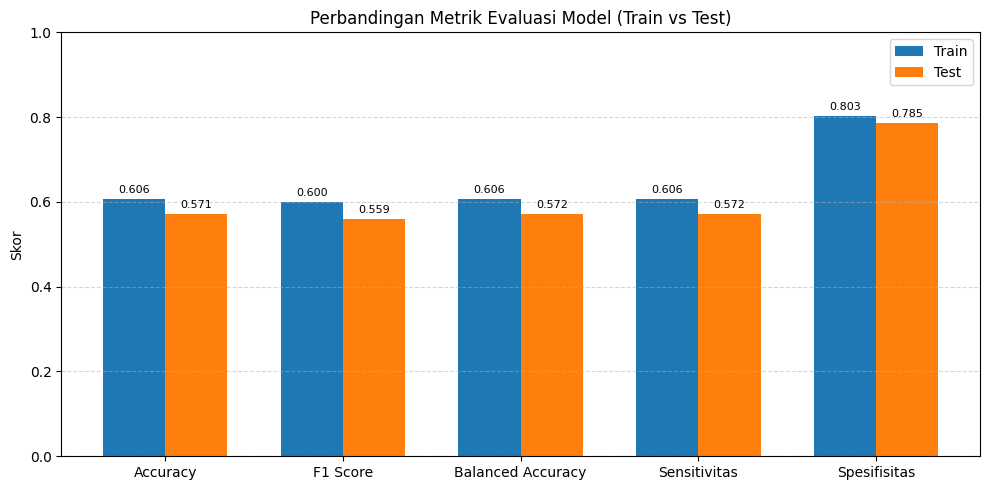

In [ ]:
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,5))

bars1 = plt.bar(
    x - width/2,
    train_values,
    width,
    label='Train'
)

bars2 = plt.bar(
    x + width/2,
    test_values,
    width,
    label='Test'
)

plt.xticks(x, labels)

plt.ylim(0, 1)

plt.title(
    'Perbandingan Metrik Evaluasi Model (Train vs Test)'
)

plt.ylabel('Skor')

plt.legend()

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

# ============================================================
# LABEL NILAI
# ============================================================

for bars in [bars1, bars2]:

    for bar in bars:

        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()

plt.show()

## Confusion Matrix

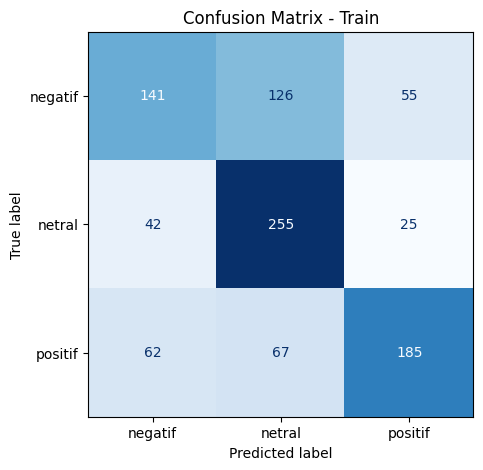

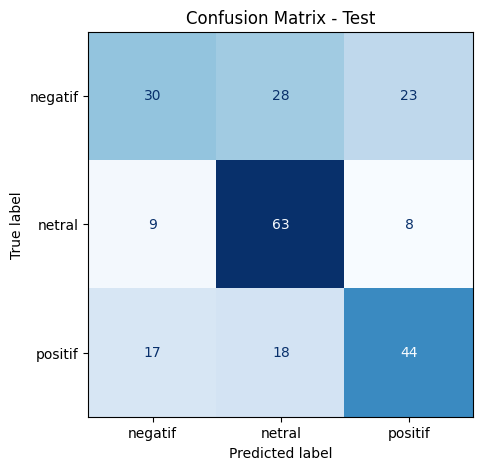

In [ ]:
cm_train = confusion_matrix(
    y_train,
    y_pred_train
)

disp_train = ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(6,5))

disp_train.plot(
    cmap='Blues',
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - Train")

plt.grid(False)

plt.show()

# ============================================================
# CONFUSION MATRIX TEST
# ============================================================

cm_test = confusion_matrix(
    y_test,
    y_pred_test
)

disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(6,5))

disp_test.plot(
    cmap='Blues',
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix - Test")

plt.grid(False)

plt.show()

# Top Word

##Top Word Frequency

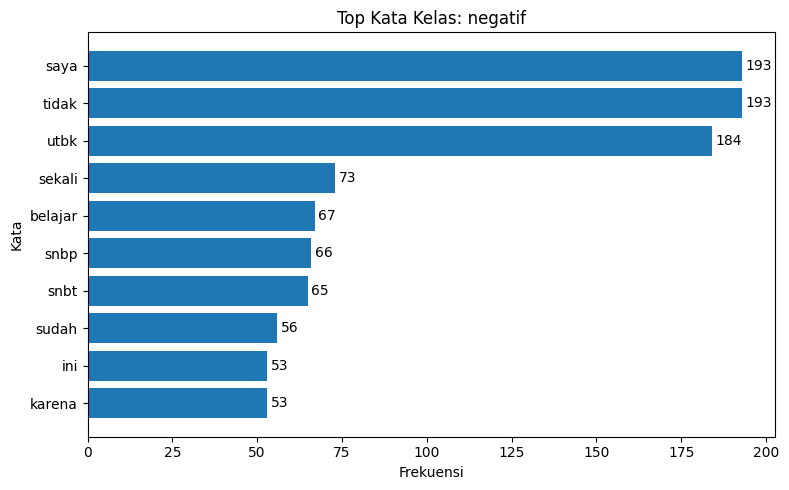

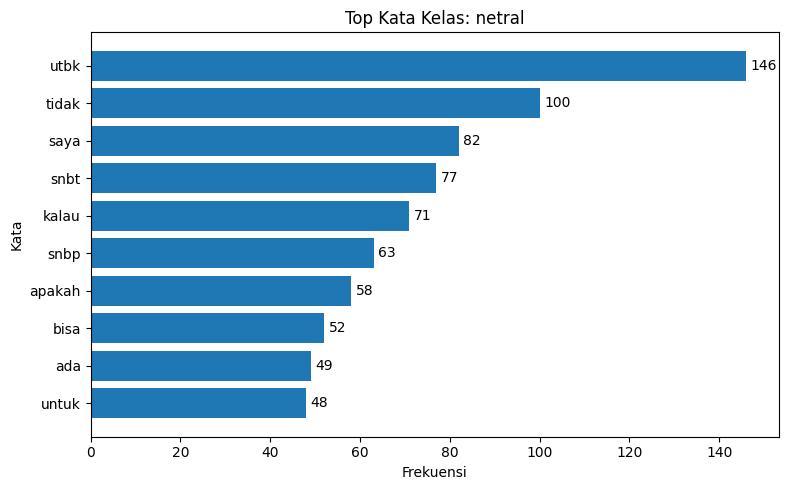

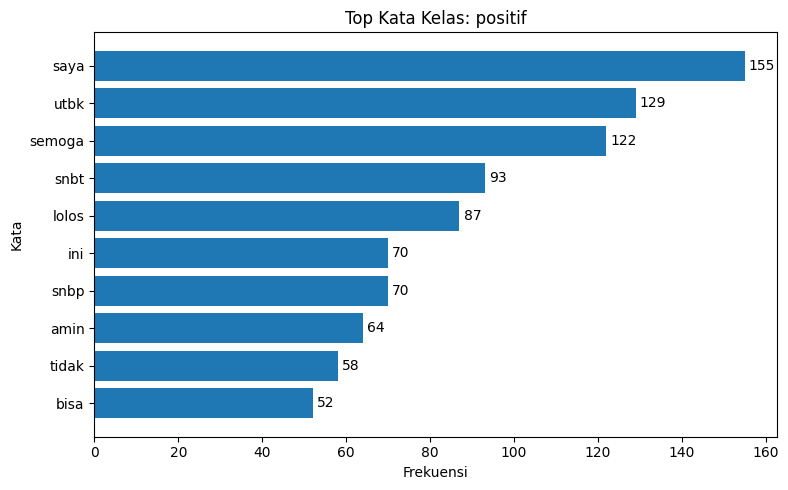

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# ============================================================
# LABEL KELAS
# ============================================================

classes = list(le.classes_)

# ============================================================
# LOOP TIAP KELAS
# ============================================================

for idx, kelas in enumerate(classes):

    # ========================================================
    # AMBIL DOKUMEN SESUAI KELAS
    # ========================================================

    teks_kelas = [

        text

        for text, label in zip(
            X_train_text,
            y_train
        )

        if label == idx
    ]

    # ========================================================
    # GABUNG SEMUA KATA
    # ========================================================

    semua_kata = ' '.join(teks_kelas).split()

    # ========================================================
    # HITUNG FREKUENSI
    # ========================================================

    counter = Counter(semua_kata)

    top_kata = counter.most_common(10)

    kata = [x[0] for x in top_kata]

    frek = [x[1] for x in top_kata]

    # ========================================================
    # BAR CHART
    # ========================================================

    plt.figure(figsize=(8,5))

    bars = plt.barh(
        kata,
        frek
    )

    plt.xlabel("Frekuensi")

    plt.ylabel("Kata")

    plt.title(
        f"Top Kata Kelas: {kelas}"
    )

    plt.gca().invert_yaxis()

    # ========================================================
    # LABEL ANGKA
    # ========================================================

    for bar in bars:

        plt.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())),
            va='center'
        )

    plt.tight_layout()

    plt.show()


===== TOP 100 KATA BERDASARKAN PREDIKSI FASTTEXT-BiLSTM KELAS negatif =====


,Kata,ChiSquare
0,belajar,88.321828
1,saya,81.516465
2,sekali,68.491767
3,karena,54.067666
4,capek,44.855144
...,...,...
95,efektif,8.730612
96,cocok,8.730612
97,sejak,8.730612
98,kebiasaan,8.730612


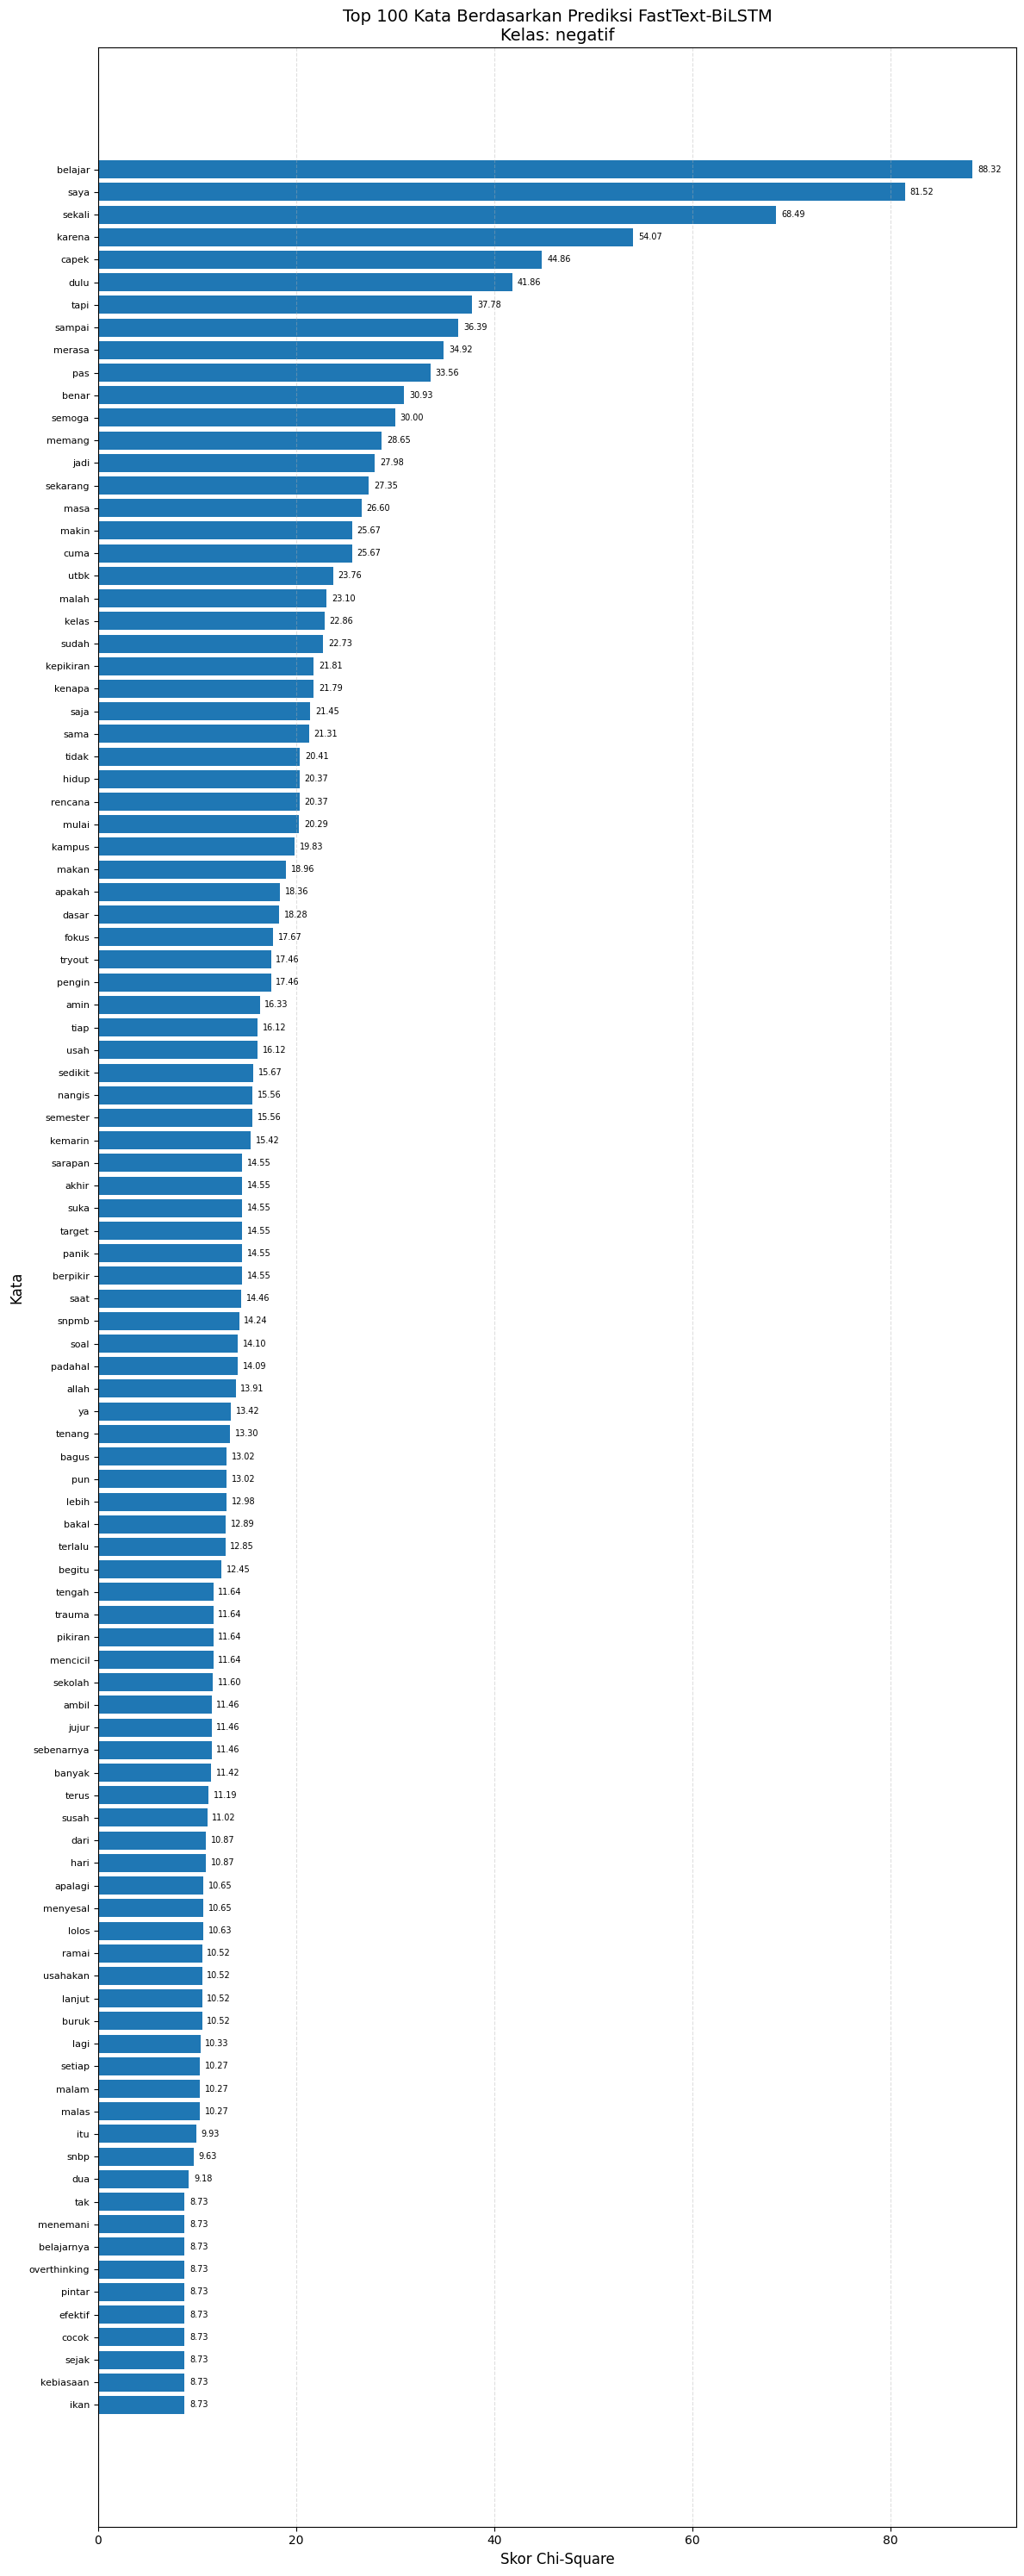


===== TOP 100 KATA BERDASARKAN PREDIKSI FASTTEXT-BiLSTM KELAS netral =====


,Kata,ChiSquare
0,semoga,96.184231
1,amin,56.913117
2,apakah,53.388415
3,saya,47.716009
4,snpmb,44.159297
...,...,...
95,kemarin,5.775603
96,makin,5.754636
97,simpan,5.691964
98,zonasi,5.691964


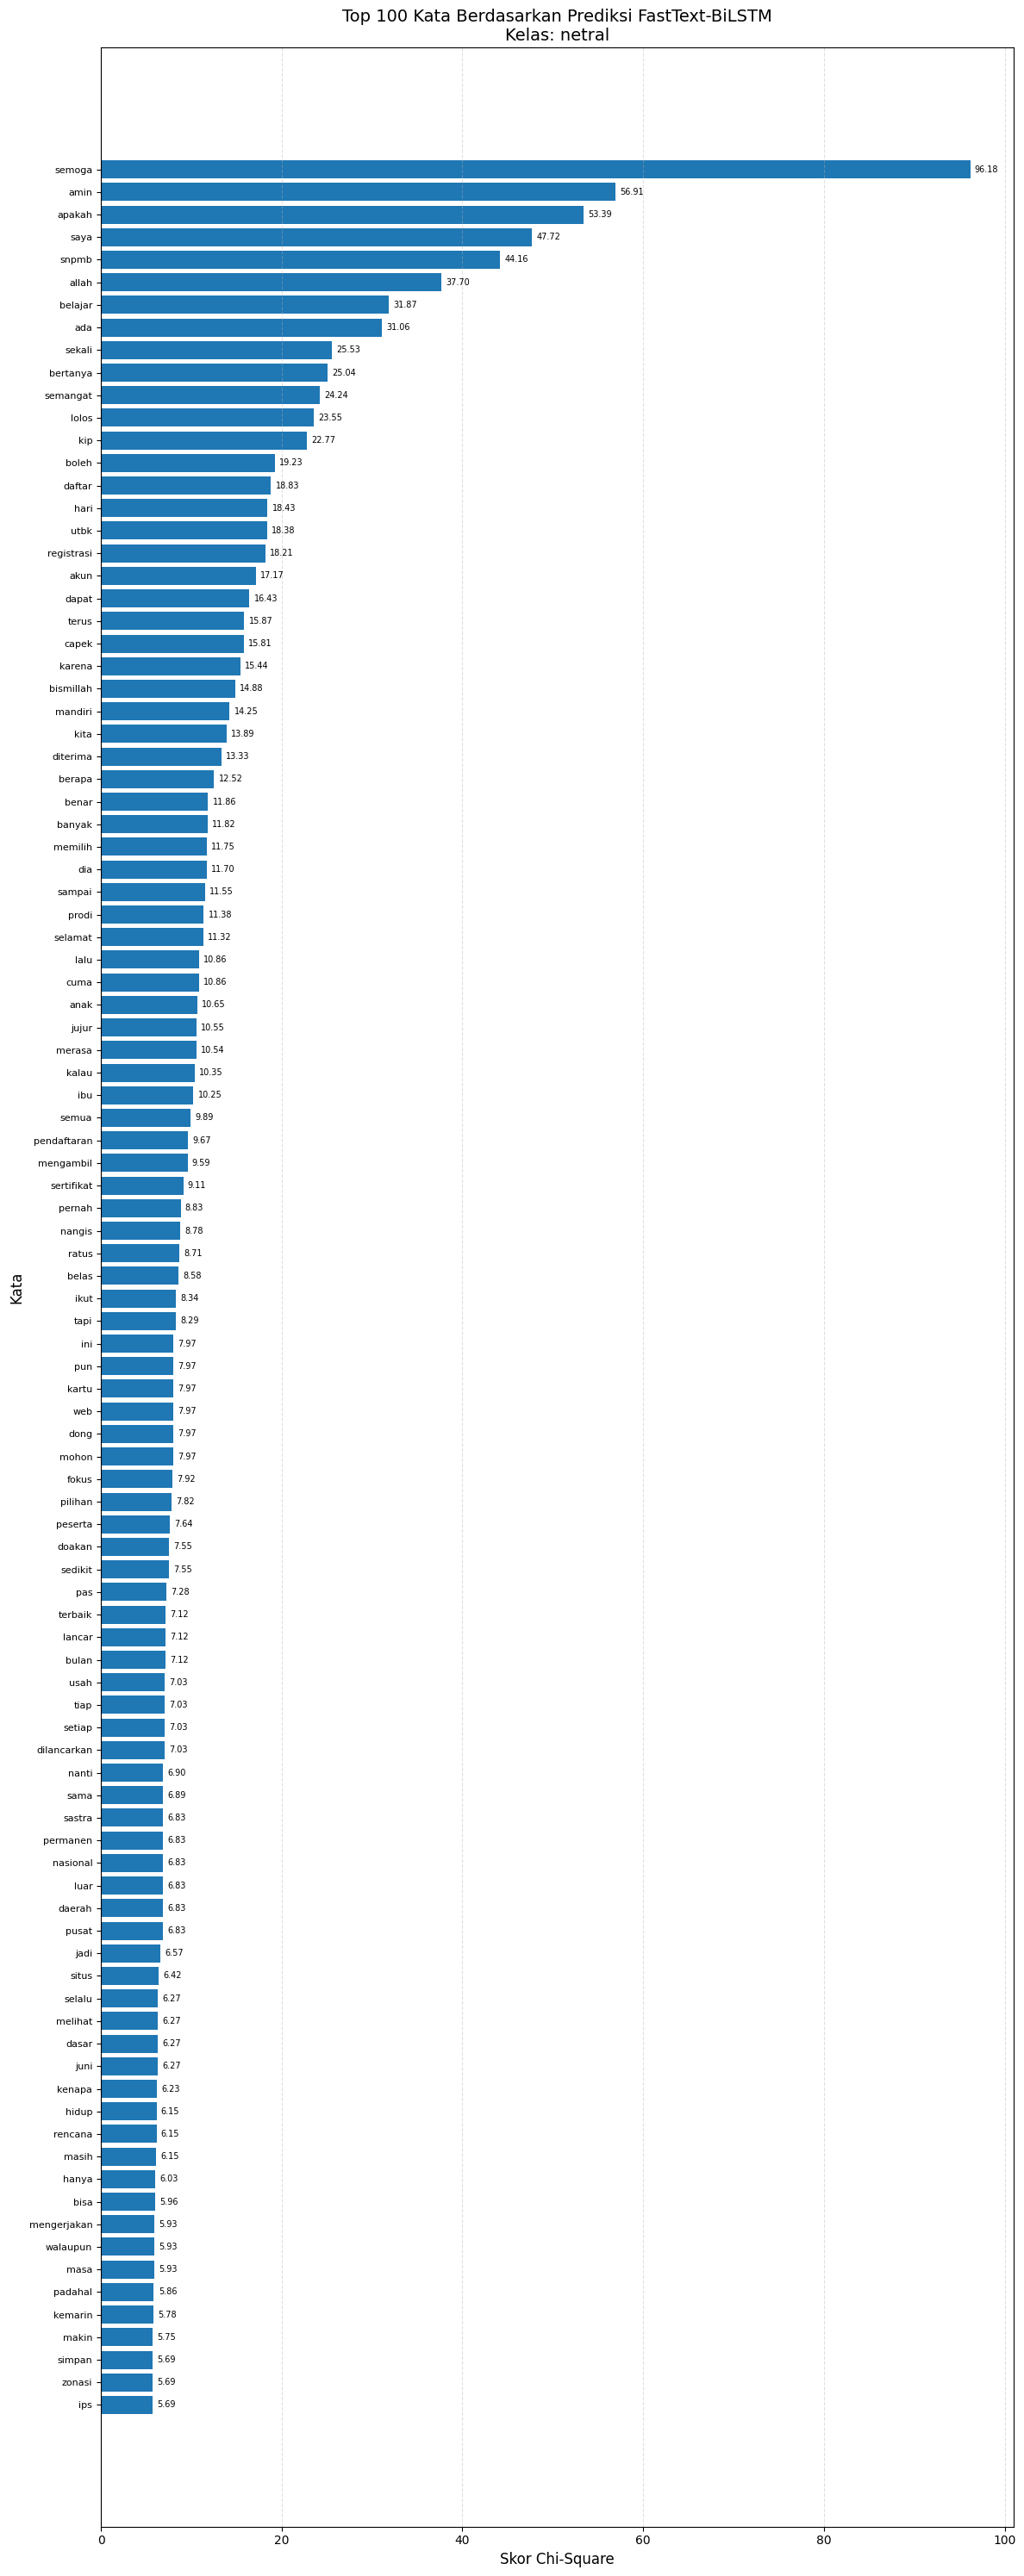


===== TOP 100 KATA BERDASARKAN PREDIKSI FASTTEXT-BiLSTM KELAS positif =====


,Kata,ChiSquare
0,semoga,265.081698
1,amin,152.679593
2,allah,109.950832
3,lolos,73.822541
4,semangat,42.422572
...,...,...
95,jangan,6.620927
96,banget,6.608612
97,tujuh,6.412664
98,anak,6.374535


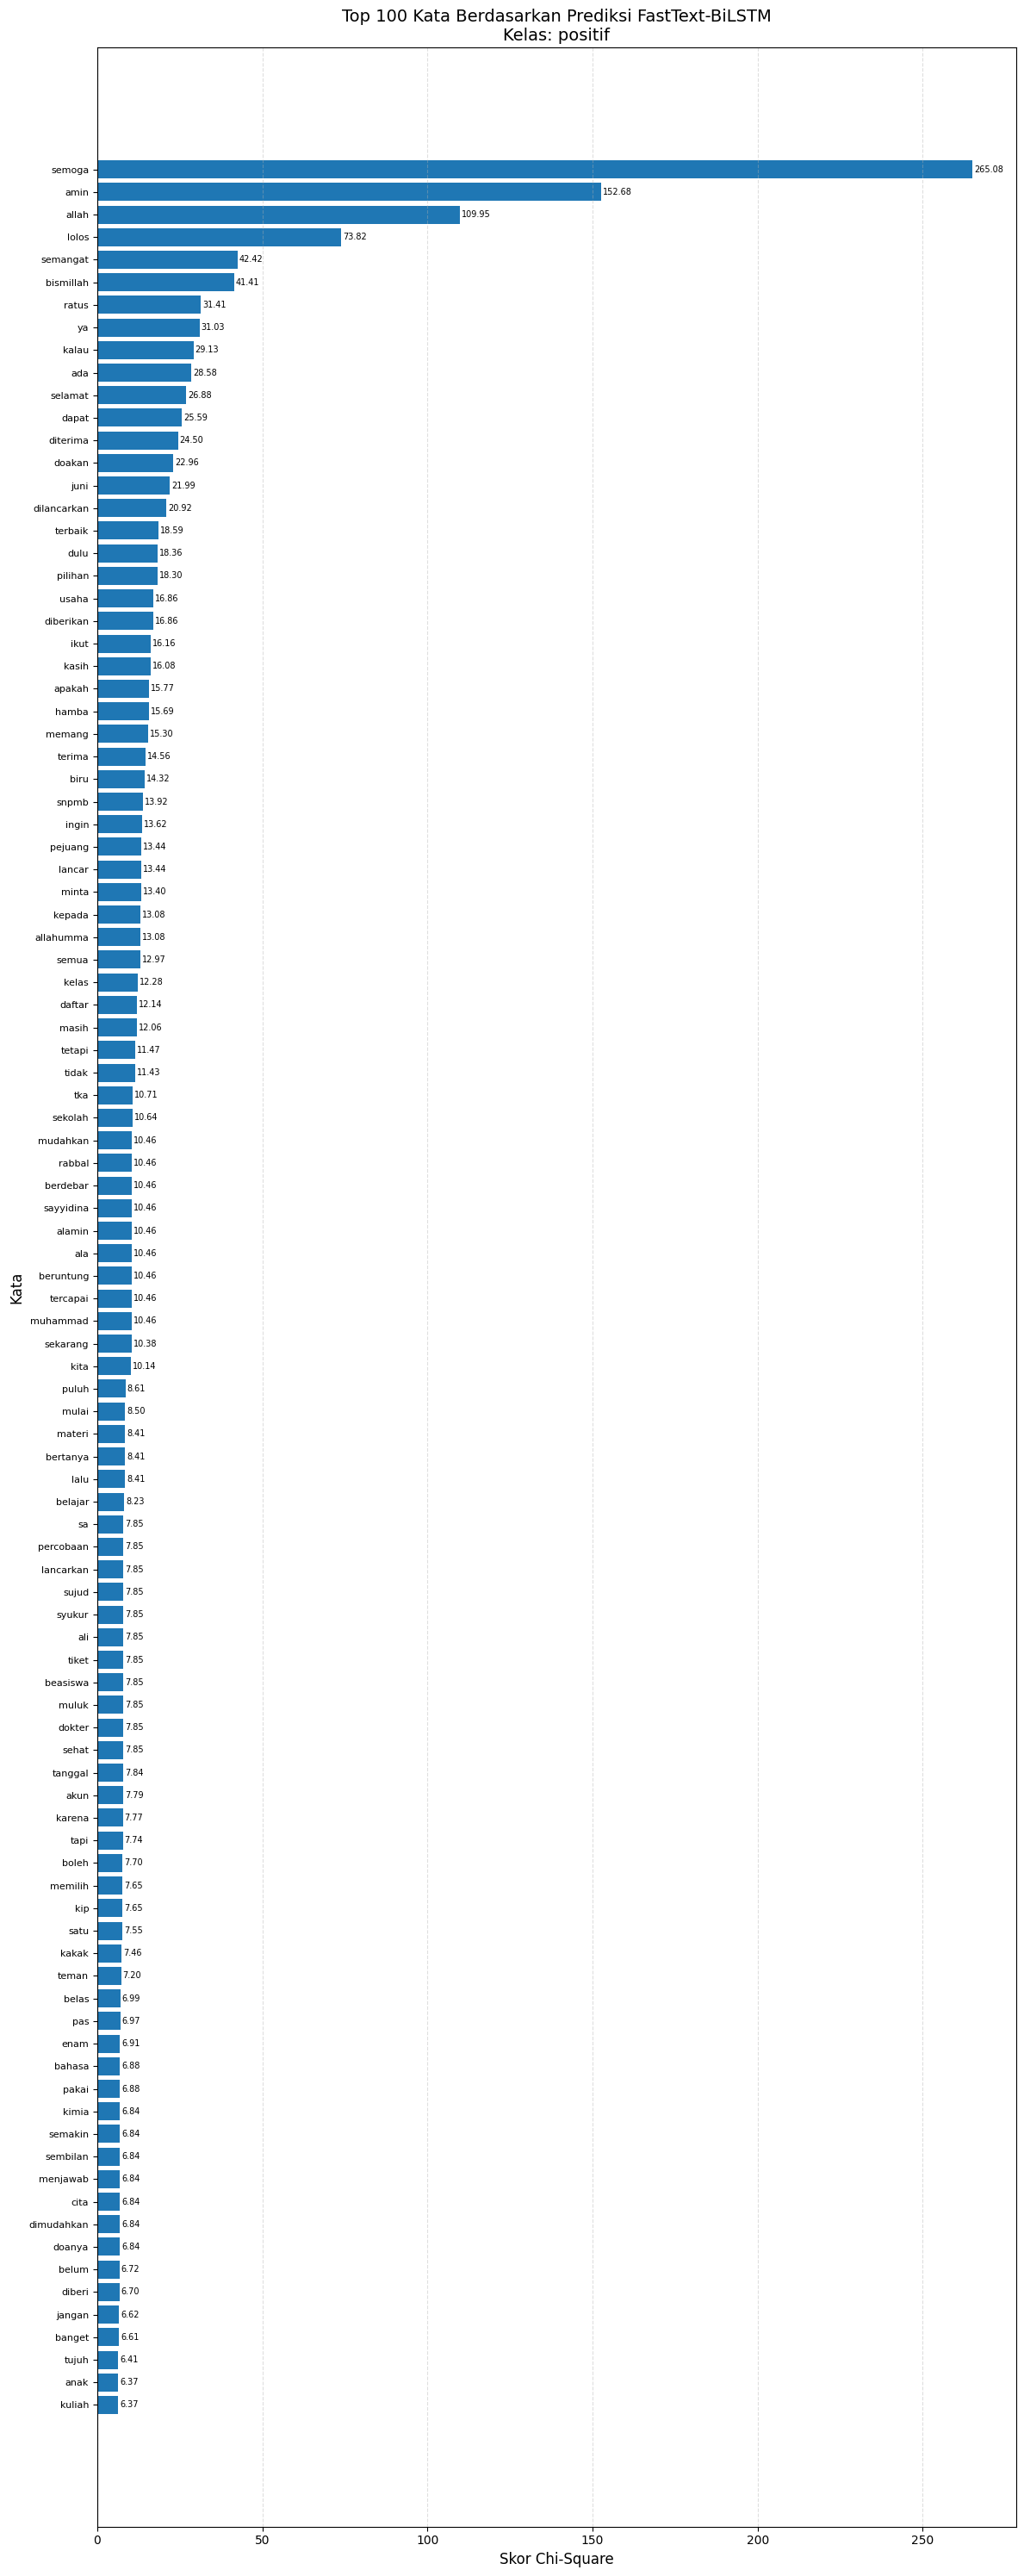

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PREDIKSI TRAIN FASTTEXT-BiLSTM
# ============================================================

y_pred_train = np.argmax(

    final_model.predict(

        X_train_best,

        verbose=0

    ),

    axis=1
)

# ============================================================
# COUNT VECTORIZER
# ============================================================

vectorizer = CountVectorizer(
    max_features=5000
)

X_count = vectorizer.fit_transform(
    X_train_text
)

feature_names = np.array(
    vectorizer.get_feature_names_out()
)

# ============================================================
# LABEL KELAS
# ============================================================

classes = list(
    le.classes_
)

# ============================================================
# LOOP PER KELAS PREDIKSI
# ============================================================

for idx, kelas in enumerate(classes):

    # ========================================================
    # ONE VS REST BERDASARKAN HASIL PREDIKSI
    # ========================================================

    y_binary = (
        y_pred_train == idx
    ).astype(int)

    # ========================================================
    # CHI-SQUARE
    # ========================================================

    chi_scores, p_values = chi2(

        X_count,

        y_binary
    )

    # ========================================================
    # TOP FITUR
    # ========================================================

    top_n = 100

    top_idx = chi_scores.argsort()[
        -top_n:
    ][::-1]

    top_kata = feature_names[
        top_idx
    ]

    top_skor = chi_scores[
        top_idx
    ]

    # ========================================================
    # DATAFRAME
    # ========================================================

    df_kata = pd.DataFrame({

        "Kata": top_kata,

        "ChiSquare": top_skor

    })

    print(
        f"\n===== TOP {top_n} KATA "
        f"BERDASARKAN PREDIKSI "
        f"FASTTEXT-BiLSTM "
        f"KELAS {kelas} ====="
    )

    display(df_kata)

    # ========================================================
    # VISUALISASI
    # ========================================================

    plt.figure(
        figsize=(12, 30)
    )

    bars = plt.barh(

        top_kata[::-1],

        top_skor[::-1]

    )

    # ========================================================
    # LABEL AXIS
    # ========================================================

    plt.xlabel(
        "Skor Chi-Square",
        fontsize=12
    )

    plt.ylabel(
        "Kata",
        fontsize=12
    )

    plt.title(

        f"Top {top_n} Kata "
        f"Berdasarkan Prediksi "
        f"FastText-BiLSTM\n"
        f"Kelas: {kelas}",

        fontsize=14
    )

    # ========================================================
    # FONT YTICK
    # ========================================================

    plt.yticks(
        fontsize=8
    )

    # ========================================================
    # LABEL NILAI BAR
    # ========================================================

    for bar in bars:

        plt.text(

            bar.get_width() + 0.5,

            bar.get_y()
            + bar.get_height()/2,

            f"{bar.get_width():.2f}",

            va='center',

            fontsize=7
        )

    # ========================================================
    # GRID
    # ========================================================

    plt.grid(

        axis='x',

        linestyle='--',

        alpha=0.4
    )

    plt.tight_layout()

    plt.show()

In [ ]:
# ============================================================
# REKAP MONITORING FASTTEXT
# ============================================================

df_monitoring = pd.DataFrame(
    time_records
)

print(
    "\n===== HASIL MONITORING FASTTEXT ====="
)

display(df_monitoring)

# ============================================================
# RINGKASAN MONITORING
# ============================================================

print(
    "\n===== RINGKASAN ====="
)

print(
    "Total Waktu :",
    round(
        df_monitoring["Waktu (detik)"].sum(),
        2
    ),
    "detik"
)

print(
    "Rata-rata RAM Sebelum :",
    round(
        df_monitoring["RAM Sebelum (GB)"].mean(),
        2
    ),
    "GB"
)

print(
    "Rata-rata RAM Sesudah :",
    round(
        df_monitoring["RAM Sesudah (GB)"].mean(),
        2
    ),
    "GB"
)

print(
    "Maksimum Kenaikan RAM :",
    round(
        df_monitoring["Kenaikan RAM (GB)"].max(),
        2
    ),
    "GB"
)

# ============================================================
# SIMPAN EXCEL
# ============================================================

output_path = (
    "/content/drive/MyDrive/Thesis/"
    "monitoring_fasttext_bilstm.xlsx"
)

df_monitoring.to_excel(

    output_path,

    index=False
)

print(
    f"\nMonitoring berhasil disimpan di:\n"
    f"{output_path}"
)


===== HASIL MONITORING FASTTEXT =====


,Metode,Tahap,Parameter,Waktu (detik),RAM Sebelum (GB),RAM Sesudah (GB),Kenaikan RAM (GB)
0,FastText + BiLSTM,Embedding Extraction,"dim=50, epoch=10, lr=0.1",0.6749,2.1371,1.6049,-0.5322
1,FastText + BiLSTM,Embedding Extraction,"dim=50, epoch=10, lr=0.5",0.6797,1.6049,1.9631,0.3582
2,FastText + BiLSTM,Embedding Extraction,"dim=50, epoch=25, lr=0.1",0.8104,1.9631,2.2719,0.3088
3,FastText + BiLSTM,Embedding Extraction,"dim=50, epoch=25, lr=0.5",0.8106,2.2719,2.5820,0.3101
4,FastText + BiLSTM,Embedding Extraction,"dim=100, epoch=10, lr=0.1",0.9431,2.5820,3.0842,0.5022
5,FastText + BiLSTM,Embedding Extraction,"dim=100, epoch=10, lr=0.5",0.9220,3.0842,3.5583,0.4741
6,FastText + BiLSTM,Embedding Extraction,"dim=100, epoch=25, lr=0.1",1.2188,3.5583,4.0277,0.4694
7,FastText + BiLSTM,Embedding Extraction,"dim=100, epoch=25, lr=0.5",1.3219,4.0277,4.5321,0.5044
8,FastText-BiLSTM,Training CV,"d50_ep10_lr0.1, ep=10, bs=64",49.6706,4.5397,6.3913,1.8516
9,FastText-BiLSTM,Training CV,"d50_ep10_lr0.1, ep=20, bs=64",44.8474,6.3913,6.6114,0.2201



===== RINGKASAN =====
Total Waktu : 822.94 detik
Rata-rata RAM Sebelum : 6.48 GB
Rata-rata RAM Sesudah : 6.77 GB
Maksimum Kenaikan RAM : 1.85 GB

Monitoring berhasil disimpan di:
/content/drive/MyDrive/Thesis/monitoring_fasttext_bilstm.xlsx


In [ ]:
# ============================================================
# EXPORT ARTIFACTS - FastText + BiLSTM
# ============================================================

import os
import json
import joblib
import numpy as np
import pandas as pd

# ============================================================
# CLASS NAMES
# ============================================================

class_names = list(
    le.classes_
)

# ============================================================
# TRAIN PREDICTIONS
# ============================================================

y_pred_train = np.argmax(

    final_model.predict(

        X_train_best,

        verbose=0
    ),

    axis=1
)

# ============================================================
# TEST PREDICTIONS
# ============================================================

y_pred_test = np.argmax(

    final_model.predict(

        X_test_final,

        verbose=0
    ),

    axis=1
)

# ============================================================
# DECODE LABELS
# ============================================================

label_asli_train = le.inverse_transform(
    y_train
)

label_pred_train = le.inverse_transform(
    y_pred_train
)

label_asli_test = le.inverse_transform(
    y_test
)

label_pred_test = le.inverse_transform(
    y_pred_test
)

# ============================================================
# SOFTMAX PROBABILITIES
# ============================================================

y_prob_train = final_model.predict(

    X_train_best,

    verbose=0
)

y_prob_test = final_model.predict(

    X_test_final,

    verbose=0
)

conf_train = np.max(
    y_prob_train,
    axis=1
)

conf_test = np.max(
    y_prob_test,
    axis=1
)

# ============================================================
# DATAFRAME TRAIN
# ============================================================

df_train_result = pd.DataFrame({

    "teks"            : X_train_text,

    "data"            : "train",

    "label_asli"      : label_asli_train,

    "label_prediksi"  : label_pred_train,

    "max_confidence"  : conf_train,

    "correct"         : (
        y_train == y_pred_train
    )
})

for idx, cls_name in enumerate(
    class_names
):

    df_train_result[
        f"prob_{cls_name}"
    ] = y_prob_train[:, idx]

# ============================================================
# DATAFRAME TEST
# ============================================================

df_test_result = pd.DataFrame({

    "teks"            : X_test_text,

    "data"            : "test",

    "label_asli"      : label_asli_test,

    "label_prediksi"  : label_pred_test,

    "max_confidence"  : conf_test,

    "correct"         : (
        y_test == y_pred_test
    )
})

for idx, cls_name in enumerate(
    class_names
):

    df_test_result[
        f"prob_{cls_name}"
    ] = y_prob_test[:, idx]

# ============================================================
# GABUNG TRAIN + TEST
# ============================================================

df_hasil_klasifikasi = pd.concat(

    [
        df_train_result,
        df_test_result
    ],

    ignore_index=True
)

display(
    df_hasil_klasifikasi.head()
)

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

output_dir = (

    "/content/drive/MyDrive/Thesis/"
    "artifacts_fasttext_bilstm"
)

os.makedirs(
    output_dir,
    exist_ok=True
)

print(
    f"\nOutput directory : "
    f"{output_dir}"
)

print(
    f"Classes : "
    f"{class_names}"
)

# ============================================================
# SAVE PREDICTIONS
# ============================================================

predictions_path = os.path.join(

    output_dir,

    "predictions_with_softmax.xlsx"
)

df_hasil_klasifikasi.to_excel(

    predictions_path,

    index=False
)

print(
    f"\n✅ Predictions : "
    f"{predictions_path}"
)

# ============================================================
# SAVE BILSTM MODEL
# ============================================================

model_path = os.path.join(

    output_dir,

    "bilstm_final_model.keras"
)

final_model.save(
    model_path
)

print(
    f"✅ BiLSTM model : "
    f"{model_path}"
)

# ============================================================
# SAVE FASTTEXT MODEL
# ============================================================

fasttext_path = os.path.join(

    output_dir,

    "fasttext_model.bin"
)

best_fasttext_model.save_model(
    fasttext_path
)

print(
    f"✅ FastText model : "
    f"{fasttext_path}"
)

# ============================================================
# SAVE LABEL ENCODER
# ============================================================

le_path = os.path.join(

    output_dir,

    "label_encoder.pkl"
)

joblib.dump(
    le,
    le_path
)

print(
    f"✅ LabelEncoder : "
    f"{le_path}"
)

# ============================================================
# SAVE METADATA
# ============================================================

metadata = {

    "model_type" : "FastText + BiLSTM",

    "fasttext_params" : {

        "dim" : int(
            best_params["dim"]
        ),

        "epoch" : int(
            best_params["epoch"]
        ),

        "lr" : float(
            best_params["lr"]
        ),

        "wordNgrams" : int(
            best_params["wordNgrams"]
        )
    },

    "bilstm_params" : {

        "epochs" : int(
            best_epochs
        ),

        "batch_size" : int(
            best_batch_size
        )
    },

    "performance" : {

        "cv_mean_accuracy" : float(
            best_acc
        ),

        "cv_std" : float(
            best_std
        ),

        "test_accuracy" : float(
            test_acc
        )
    },

    "data_info" : {

        "num_train" : len(
            X_train_text
        ),

        "num_test" : len(
            X_test_text
        ),

        "num_classes" : len(
            class_names
        ),

        "class_names" : class_names
    }
}

metadata_path = os.path.join(

    output_dir,

    "metadata.json"
)

with open(
    metadata_path,
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=2
    )

print(
    f"✅ Metadata : "
    f"{metadata_path}"
)

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 60)

print(
    "EXPORT SUMMARY - FastText + BiLSTM"
)

print("=" * 60)

for fname in sorted(
    os.listdir(output_dir)
):

    fpath = os.path.join(
        output_dir,
        fname
    )

    size_mb = (
        os.path.getsize(fpath)
        / (1024 * 1024)
    )

    print(
        f"{fname:<35}"
        f"{size_mb:>8.2f} MB"
    )

print("=" * 60)

print(
    f"\n📂 Folder : "
    f"{output_dir}"
)

,teks,data,label_asli,label_prediksi,max_confidence,correct,prob_negatif,prob_netral,prob_positif
0,agak menyesal ikut tka harusnya saya fokus snb...,train,negatif,negatif,0.343784,True,0.343784,0.332257,0.323959
1,lolos utbk tidak kak kalau iya universitas pr...,train,netral,netral,0.364909,True,0.284998,0.364909,0.350093
2,menuju lolos snbt,train,positif,positif,0.356758,True,0.303476,0.339766,0.356758
3,berita baik untuk kamu kawan pajak mau ikut s...,train,positif,netral,0.347676,False,0.317186,0.347676,0.335138
4,saya mau tanya lokasi ujian biasanya diumumkan...,train,netral,netral,0.359411,True,0.306031,0.359411,0.334558



Output directory : /content/drive/MyDrive/Thesis/artifacts_fasttext_bilstm
Classes : ['negatif', 'netral', 'positif']

✅ Predictions : /content/drive/MyDrive/Thesis/artifacts_fasttext_bilstm/predictions_with_softmax.xlsx
✅ BiLSTM model : /content/drive/MyDrive/Thesis/artifacts_fasttext_bilstm/bilstm_final_model.keras
✅ FastText model : /content/drive/MyDrive/Thesis/artifacts_fasttext_bilstm/fasttext_model.bin
✅ LabelEncoder : /content/drive/MyDrive/Thesis/artifacts_fasttext_bilstm/label_encoder.pkl
✅ Metadata : /content/drive/MyDrive/Thesis/artifacts_fasttext_bilstm/metadata.json

EXPORT SUMMARY - FastText + BiLSTM
bilstm_final_model.keras               1.10 MB
fasttext_model.bin                   763.33 MB
label_encoder.pkl                      0.00 MB
metadata.json                          0.00 MB
predictions_with_softmax.xlsx          0.13 MB

📂 Folder : /content/drive/MyDrive/Thesis/artifacts_fasttext_bilstm
